<a href="https://colab.research.google.com/github/anushah-200/SATARK_AI/blob/main/notebooks/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/anushah-200/SATARK_AI.git
%cd SATARK_AI

Cloning into 'SATARK_AI'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 74 (delta 30), reused 3 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 25.51 KiB | 3.64 MiB/s, done.
Resolving deltas: 100% (30/30), done.
/content/SATARK_AI


In [5]:
!pip install -q "meteostat==1.6.8"

In [3]:
!pip install -q meteostat pandas numpy scikit-learn matplotlib plotly streamlit joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 105.5 MB/s eta 0:00:00


In [6]:
!pip install -q pandas==2.2.3

In [1]:
import pandas as pd
import numpy as np
import meteostat

print("Pandas version:", pd.__version__)
print("Meteostat version:", meteostat.__version__)

Pandas version: 2.2.3
Meteostat version: 1.6.8


In [2]:
from meteostat import Stations

# Delhi-NCR coordinates
latitude = 28.6139
longitude = 77.2090

# Find the 20 nearest weather stations
stations = Stations()
nearby_stations = stations.nearby(latitude, longitude).fetch(20)

print(nearby_stations[
    ["name", "country", "region", "latitude", "longitude", "elevation"]
])

                         name country region  latitude  longitude  elevation
id                                                                          
42182  New Delhi / Safdarjung      IN     DL   28.5833    77.2000      211.0
42181       New Delhi / Palam      IN     DL   28.5667    77.1167      220.0
42139                  Meerut      IN     UP   29.0167    77.6333      221.0
42176                  Rohtak      IN     HR   28.8333    76.5833        0.0
42262                 Aligarh      IN     UP   27.8833    78.0667      186.0
42137                  Karnal      IN     HR   29.7000    77.0333      248.0
42177                 Narnaul      IN     HR   28.0000    76.0833      306.0
42255                   Alwar      IN     RJ   27.5000    76.5833      270.0
42140                 Roorkee      IN     UP   29.8500    77.8833      273.0
42187               Moradabad      IN     UP   28.8333    78.7500        0.0
42131                  Hissar      IN     HR   29.1667    75.7333      216.0

In [3]:
from meteostat import Hourly
from datetime import datetime

station_ids = ["42182", "42181", "42176", "42139", "42131"]

start = datetime(2024, 1, 1)
end = datetime(2025, 1, 1)

for station in station_ids:
    data = Hourly(station, start, end).fetch()

    print(
        station,
        "→",
        len(data),
        "records",
        "|",
        data.index.min(),
        "to",
        data.index.max()
    )

42182 → 8785 records | 2024-01-01 00:00:00 to 2025-01-01 00:00:00


42181 → 8785 records | 2024-01-01 00:00:00 to 2025-01-01 00:00:00


42176 → 8617 records | 2024-01-01 00:00:00 to 2025-01-01 00:00:00


42139 → 8626 records | 2024-01-01 00:00:00 to 2025-01-01 00:00:00


42131 → 8643 records | 2024-01-01 00:00:00 to 2025-01-01 00:00:00


In [4]:
from meteostat import Hourly
from datetime import datetime

data = Hourly(
    "42182",
    datetime(2024, 1, 1),
    datetime(2025, 1, 1)
).fetch()

print("Shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

print("\nFirst 5 rows:")
display(data.head())

Shape: (8785, 11)

Columns:
['temp', 'dwpt', 'rhum', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt', 'pres', 'tsun', 'coco']

First 5 rows:


,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
time,,,,,,,,,,,
2024-01-01 00:00:00,10.8,10.0,95.0,0.0,NaN,0.0,0.0,NaN,1018.9,NaN,5.0
2024-01-01 01:00:00,9.2,8.9,98.0,0.0,NaN,281.0,1.8,NaN,1019.6,NaN,5.0
2024-01-01 02:00:00,9.4,8.9,97.0,0.0,NaN,301.0,1.8,NaN,1020.2,NaN,5.0
2024-01-01 03:00:00,9.6,8.8,95.0,0.0,NaN,325.0,1.8,NaN,1020.7,NaN,5.0
2024-01-01 04:00:00,10.7,9.6,93.0,0.0,NaN,281.0,1.8,NaN,1020.8,NaN,5.0


In [5]:
from meteostat import Hourly
from datetime import datetime

station_ids = ["42182", "42181", "42176", "42139", "42131"]

start = datetime(2025, 1, 1)
end = datetime(2026, 1, 1)

for station in station_ids:
    data = Hourly(station, start, end).fetch()

    print(
        station,
        "→",
        len(data),
        "records",
        "|",
        data.index.min(),
        "to",
        data.index.max()
    )

42182 → 8761 records | 2025-01-01 00:00:00 to 2026-01-01 00:00:00


42181 → 8761 records | 2025-01-01 00:00:00 to 2026-01-01 00:00:00


42176 → 8517 records | 2025-01-01 00:00:00 to 2026-01-01 00:00:00


42139 → 8524 records | 2025-01-01 00:00:00 to 2026-01-01 00:00:00


42131 → 8537 records | 2025-01-01 00:00:00 to 2026-01-01 00:00:00


In [6]:
from meteostat import Hourly
from datetime import datetime

data = Hourly(
    "42182",
    datetime(2025, 1, 1),
    datetime(2026, 1, 1)
).fetch()

print("Shape:", data.shape)

print("\nColumns:")
print(data.columns.tolist())

print("\nFirst 5 rows:")
display(data.head())

Shape: (8761, 11)

Columns:
['temp', 'dwpt', 'rhum', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt', 'pres', 'tsun', 'coco']

First 5 rows:


,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
time,,,,,,,,,,,
2025-01-01 00:00:00,10.4,9.2,92.0,0.0,NaN,268.0,3.6,NaN,1019.2,NaN,5.0
2025-01-01 01:00:00,8.4,7.5,94.0,0.0,NaN,261.0,3.7,NaN,1019.5,NaN,5.0
2025-01-01 02:00:00,8.8,7.6,92.0,0.0,NaN,257.0,5.5,NaN,1019.7,NaN,5.0
2025-01-01 03:00:00,10.0,7.9,87.0,0.0,NaN,270.0,5.4,NaN,1020.2,NaN,5.0
2025-01-01 04:00:00,10.9,8.1,83.0,0.0,NaN,272.0,5.5,NaN,1020.2,NaN,5.0


In [7]:
from meteostat import Hourly
from datetime import datetime
import pandas as pd

stations_info = {
    "42182": {
        "name": "Safdarjung",
        "latitude": 28.5833,
        "longitude": 77.2000
    },
    "42181": {
        "name": "Palam",
        "latitude": 28.5667,
        "longitude": 77.1167
    },
    "42176": {
        "name": "Rohtak",
        "latitude": 28.8333,
        "longitude": 76.5833
    },
    "42139": {
        "name": "Meerut",
        "latitude": 29.0167,
        "longitude": 77.6333
    },
    "42131": {
        "name": "Hissar",
        "latitude": 29.1667,
        "longitude": 75.7333
    }
}

start = datetime(2025, 1, 1)
end = datetime(2026, 1, 1)

all_data = []

for station_id, info in stations_info.items():

    print("Downloading:", info["name"])

    df = Hourly(station_id, start, end).fetch()

    df = df.reset_index()

    df["station_id"] = station_id
    df["station_name"] = info["name"]
    df["latitude"] = info["latitude"]
    df["longitude"] = info["longitude"]

    df = df.rename(columns={
        "time": "timestamp",
        "temp": "temperature",
        "rhum": "humidity",
        "pres": "pressure",
        "wspd": "wind_speed",
        "wdir": "wind_direction"
    })

    df = df[
        [
            "timestamp",
            "station_id",
            "station_name",
            "latitude",
            "longitude",
            "temperature",
            "humidity",
            "pressure",
            "wind_speed",
            "wind_direction"
        ]
    ]

    all_data.append(df)

# Combine all stations
aws_data = pd.concat(all_data, ignore_index=True)

# Sort by station and time
aws_data = aws_data.sort_values(
    ["station_id", "timestamp"]
).reset_index(drop=True)

print("\nFinal dataset shape:", aws_data.shape)

print("\nRecords per station:")
print(aws_data["station_name"].value_counts())

print("\nFirst 5 rows:")
display(aws_data.head())

Downloading: Safdarjung
Downloading: Palam
Downloading: Rohtak
Downloading: Meerut
Downloading: Hissar

Final dataset shape: (43100, 10)

Records per station:
station_name
Safdarjung    8761
Palam         8761
Hissar        8537
Meerut        8524
Rohtak        8517
Name: count, dtype: int64

First 5 rows:


,timestamp,station_id,station_name,latitude,longitude,temperature,humidity,pressure,wind_speed,wind_direction
0,2025-01-01 00:00:00,42131,Hissar,29.1667,75.7333,5.4,97.0,1020.7,0.0,0.0
1,2025-01-01 01:00:00,42131,Hissar,29.1667,75.7333,6.1,98.0,1019.5,5.0,283.0
2,2025-01-01 02:00:00,42131,Hissar,29.1667,75.7333,6.1,94.0,1019.8,5.4,274.0
3,2025-01-01 03:00:00,42131,Hissar,29.1667,75.7333,8.0,97.0,1021.5,0.0,0.0
4,2025-01-01 04:00:00,42131,Hissar,29.1667,75.7333,7.6,96.0,1020.8,6.8,276.0


In [8]:
print("Dataset shape:")
print(aws_data.shape)

print("\nMissing values:")
print(aws_data.isnull().sum())

print("\nData types:")
print(aws_data.dtypes)

print("\nRecords per station:")
print(aws_data["station_name"].value_counts())

print("\nTemperature statistics:")
print(aws_data["temperature"].describe())

print("\nHumidity statistics:")
print(aws_data["humidity"].describe())

print("\nPressure statistics:")
print(aws_data["pressure"].describe())

Dataset shape:
(43100, 10)

Missing values:
timestamp           0
station_id          0
station_name        0
latitude            0
longitude           0
temperature         0
humidity            0
pressure            0
wind_speed          0
wind_direction    150
dtype: int64

Data types:
timestamp         datetime64[ns]
station_id                object
station_name              object
latitude                 float64
longitude                float64
temperature              float64
humidity                 float64
pressure                 float64
wind_speed               float64
wind_direction           float64
dtype: object

Records per station:
station_name
Safdarjung    8761
Palam         8761
Hissar        8537
Meerut        8524
Rohtak        8517
Name: count, dtype: int64

Temperature statistics:
count    43100.000000
mean        24.361745
std          7.864331
min          4.000000
25%         18.300000
50%         26.000000
75%         30.100000
max         44.000000
Name: tem

In [9]:
import os

# Create required directories
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("data/synthetic", exist_ok=True)

# Save raw dataset
raw_path = "data/raw/aws_data.csv"
aws_data.to_csv(raw_path, index=False)

print("Saved successfully!")
print("File:", raw_path)
print("Rows:", len(aws_data))
print("Columns:", len(aws_data.columns))

Saved successfully!
File: data/raw/aws_data.csv
Rows: 43100
Columns: 10


In [10]:
for station in aws_data["station_id"].unique():

    station_data = aws_data[
        aws_data["station_id"] == station
    ].sort_values("timestamp")

    time_diff = station_data["timestamp"].diff()

    print("\nStation:", station)
    print("Name:", station_data["station_name"].iloc[0])

    print("Most common time intervals:")
    print(time_diff.value_counts().head(5))

    print("Number of gaps greater than 1 hour:",
          (time_diff > pd.Timedelta(hours=1)).sum())


Station: 42131
Name: Hissar
Most common time intervals:
timestamp
0 days 01:00:00    8457
0 days 03:00:00      55
0 days 06:00:00      22
0 days 02:00:00       1
0 days 04:00:00       1
Name: count, dtype: int64
Number of gaps greater than 1 hour: 79

Station: 42139
Name: Meerut
Most common time intervals:
timestamp
0 days 01:00:00    8457
0 days 06:00:00      35
0 days 03:00:00      29
0 days 02:00:00       1
0 days 04:00:00       1
Name: count, dtype: int64
Number of gaps greater than 1 hour: 66

Station: 42176
Name: Rohtak
Most common time intervals:
timestamp
0 days 01:00:00    8457
0 days 06:00:00      42
0 days 03:00:00      15
0 days 02:00:00       1
0 days 04:00:00       1
Name: count, dtype: int64
Number of gaps greater than 1 hour: 59

Station: 42181
Name: Palam
Most common time intervals:
timestamp
0 days 01:00:00    8760
Name: count, dtype: int64
Number of gaps greater than 1 hour: 0

Station: 42182
Name: Safdarjung
Most common time intervals:
timestamp
0 days 01:00:00    

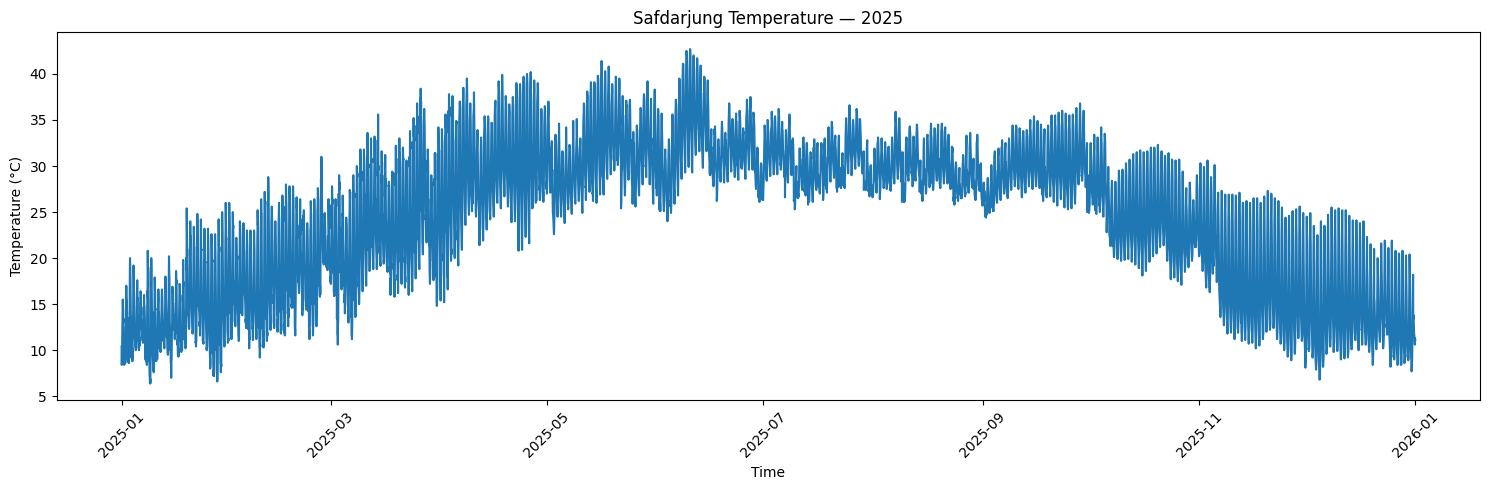

In [11]:
import matplotlib.pyplot as plt

station_data = aws_data[
    aws_data["station_id"] == "42182"
].sort_values("timestamp")

plt.figure(figsize=(15, 5))

plt.plot(
    station_data["timestamp"],
    station_data["temperature"]
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Safdarjung Temperature — 2025")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

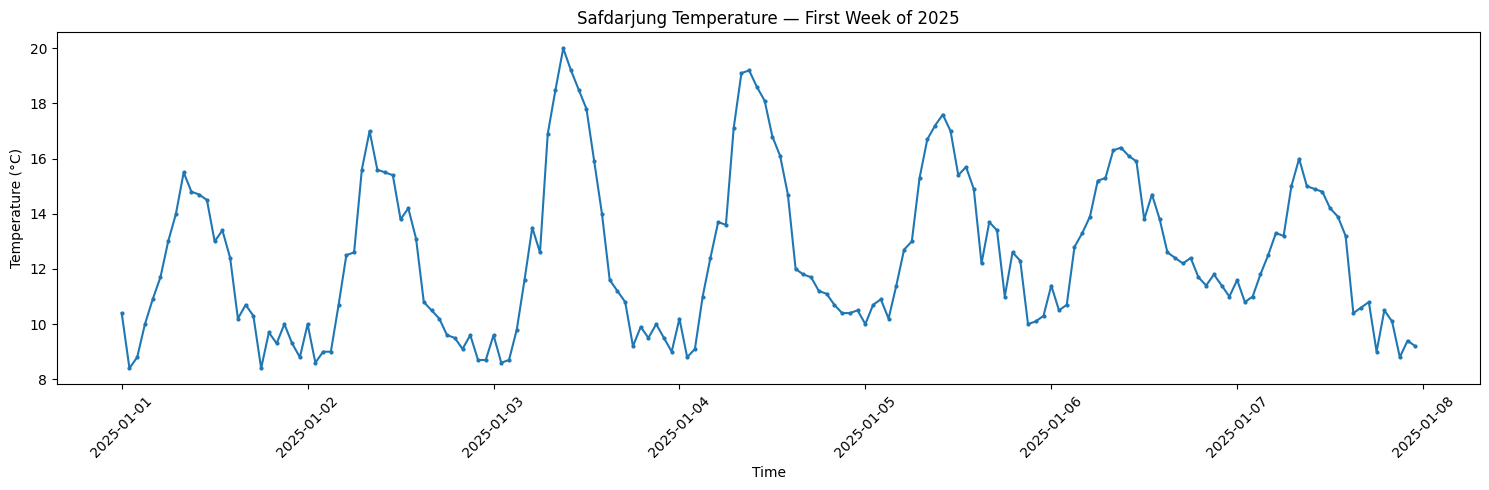

In [12]:
station_data = aws_data[
    aws_data["station_id"] == "42182"
].sort_values("timestamp")

# Select the first 7 days
week_data = station_data[
    (station_data["timestamp"] >= "2025-01-01") &
    (station_data["timestamp"] < "2025-01-08")
]

plt.figure(figsize=(15, 5))

plt.plot(
    week_data["timestamp"],
    week_data["temperature"],
    marker="o",
    markersize=2
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Safdarjung Temperature — First Week of 2025")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
meteostat_data = aws_data.copy()

print("Meteostat dataset shape:", meteostat_data.shape)

Meteostat dataset shape: (43100, 10)


In [14]:
raw_path = "data/raw/aws_data.csv"
aws_data.to_csv(raw_path, index=False)

In [15]:
import os

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("data/synthetic", exist_ok=True)

raw_path = "data/raw/meteostat_data.csv"

meteostat_data.to_csv(
    raw_path,
    index=False
)

print("Saved successfully!")
print("File:", raw_path)
print("Rows:", len(meteostat_data))
print("Columns:", len(meteostat_data.columns))

Saved successfully!
File: data/raw/meteostat_data.csv
Rows: 43100
Columns: 10


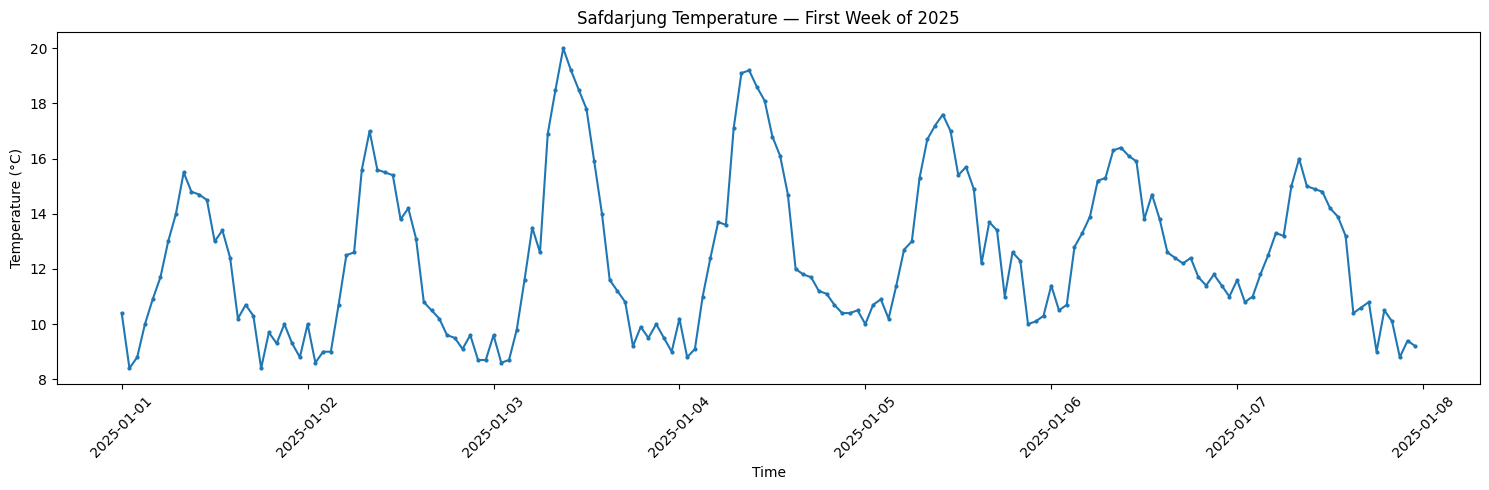

In [16]:
station_data = meteostat_data[
    meteostat_data["station_id"] == "42182"
].sort_values("timestamp")

week_data = station_data[
    (station_data["timestamp"] >= "2025-01-01") &
    (station_data["timestamp"] < "2025-01-08")
]

plt.figure(figsize=(15, 5))

plt.plot(
    week_data["timestamp"],
    week_data["temperature"],
    marker="o",
    markersize=2
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Safdarjung Temperature — First Week of 2025")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()